In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import imblearn.under_sampling

In [4]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [5]:
from sklearn.datasets import make_classification

In [6]:
?make_classification

Signature:
make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
)
Docstring:
Generate a random n-class classification problem.

This initially creates clusters of points normally distributed (std=1)
about vertices of an ``n_informative``-dimensional hypercube with sides of
length ``2*class_sep`` and assigns an equal number of clusters to each
class. It introduces interdependence between these features and adds
various types of further noise to the data.

Without shuffling, ``X`` horizontally stacks features in the following
order: the primary ``n_informative`` features, followed by ``n_redundant``
linear combinations of the informative features, followed by ``n_repeated``
duplicates, drawn randomly with replacement from the infor

In [14]:
def make_data(sep):

    X,y = make_classification(n_samples=1000,
                              n_features=2,
                              n_redundant=0,
                              n_clusters_per_class=1,
                              weights=[0.99],
                              class_sep=sep,
                              random_state=0)
    
    X = pd.DataFrame(data=X, columns=['varA', 'varB'])
    y = pd.Series(y)

    return X,y

In [8]:
from imblearn.under_sampling import EditedNearestNeighbours

In [9]:
?EditedNearestNeighbours

Init signature:
EditedNearestNeighbours(
    *,
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=None,
)
Docstring:     
Undersample based on the edited nearest neighbour method.

This method cleans the dataset by removing samples close to the
decision boundary. It removes observations from the majority class or
classes when any or most of its closest neighours are from a different class.

Read more in the :ref:`User Guide <edited_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all 

In [10]:
enn = EditedNearestNeighbours(sampling_strategy='auto',
                              n_neighbors=3,
                              kind_sel='all',
                              n_jobs=-1)

In [74]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [75]:
from imblearn.under_sampling import RepeatedEditedNearestNeighbours

In [76]:
?RepeatedEditedNearestNeighbours

Init signature:
RepeatedEditedNearestNeighbours(
    *,
    sampling_strategy='auto',
    n_neighbors=3,
    max_iter=100,
    kind_sel='all',
    n_jobs=None,
)
Docstring:     
Undersample based on the repeated edited nearest neighbour method.

This method repeats the :class:`EditedNearestNeighbours` algorithm several times.
The repetitions will stop when i) the maximum number of iterations is reached,
or ii) no more observations are being removed, or iii) one of the majority classes
becomes a minority class or iv) one of the majority classes disappears
during undersampling.

Read more in the :ref:`User Guide <edited_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minor

In [106]:
renn = RepeatedEditedNearestNeighbours(
    sampling_strategy='auto',
    n_neighbors=3,
    max_iter=100,
    kind_sel='all',
    n_jobs=None,
)

In [107]:
X,y = make_data(sep=2)

In [108]:
X_resampled, y_resampled = renn.fit_resample(X,y)

# Repeated Edited Nearest Neighbours

In [80]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [81]:
from imblearn.under_sampling import EditedNearestNeighbours

In [82]:
?EditedNearestNeighbours

Init signature:
EditedNearestNeighbours(
    *,
    sampling_strategy='auto',
    n_neighbors=3,
    kind_sel='all',
    n_jobs=None,
)
Docstring:     
Undersample based on the edited nearest neighbour method.

This method cleans the dataset by removing samples close to the
decision boundary. It removes observations from the majority class or
classes when any or most of its closest neighours are from a different class.

Read more in the :ref:`User Guide <edited_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all 

In [109]:
X.shape, X_resampled.shape

((1000, 2), (977, 2))

<Axes: xlabel='varA', ylabel='varB'>

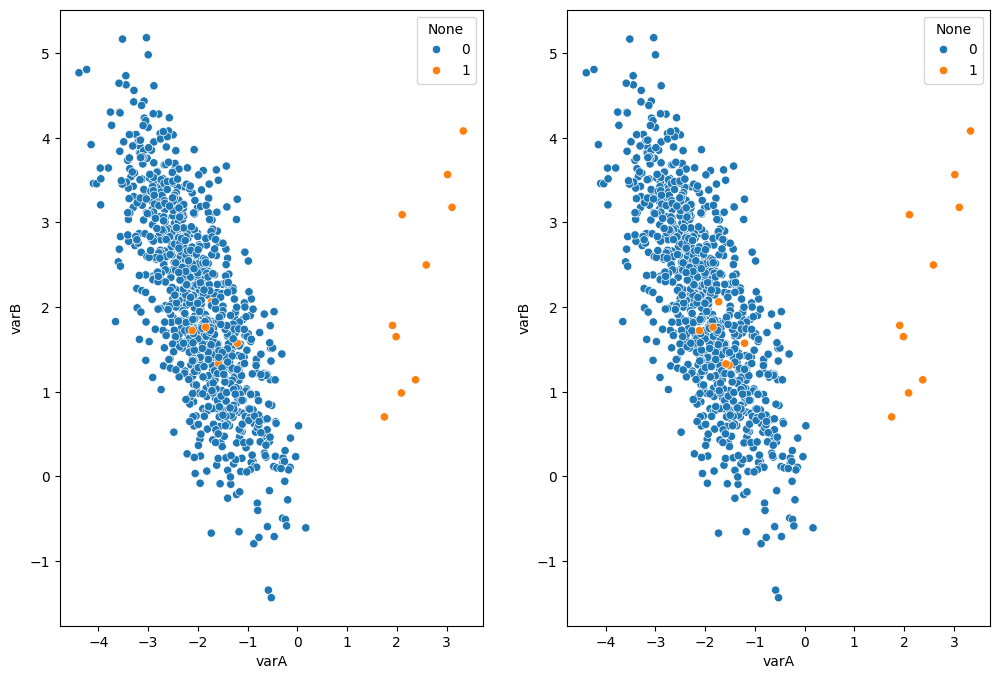

In [110]:
plt.figure(figsize=(12,8))
plt.subplot(121)
sns.scatterplot(data=X, x='varA', y='varB', hue=y)

plt.subplot(122)
sns.scatterplot(data=X_resampled, x='varA', y='varB', hue=y_resampled)

In [85]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)
X_train.shape, X_test.shape

((700, 2), (300, 2))

In [113]:
X_resampled, y_resampled = renn.fit_resample(X_train, y_train)

In [114]:
from sklearn.ensemble import RandomForestClassifier

In [115]:
from sklearn.metrics import roc_auc_score

In [116]:
def runRandomForests(X_train, X_test, y_train, y_test):

    rf = RandomForestClassifier(n_estimators=200,
                                max_depth=4,
                                criterion='entropy',
                                random_state=0)
    rf.fit(X_train, y_train)

    y_prob = rf.predict_proba(X_train)[:,1]
    print('RF train roc-auc score: {}'.format(roc_auc_score(y_train, y_prob)))

    y_prob = rf.predict_proba(X_test)[:,1]
    print('RF test roc-auc score: {}'.format(roc_auc_score(y_test, y_prob)))

In [117]:
runRandomForests(X_train, X_test, y_train, y_test)

RF train roc-auc score: 1.0
RF test roc-auc score: 0.8547155402825506


In [118]:
runRandomForests(X_resampled, X_test, y_resampled, y_test)

RF train roc-auc score: 1.0
RF test roc-auc score: 0.856815578465063


In [119]:
from matplotlib.colors import ListedColormap

In [120]:
classifier = RandomForestClassifier(n_estimators=200,
                criterion='entropy',
                max_depth=4,
                random_state=0)


/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


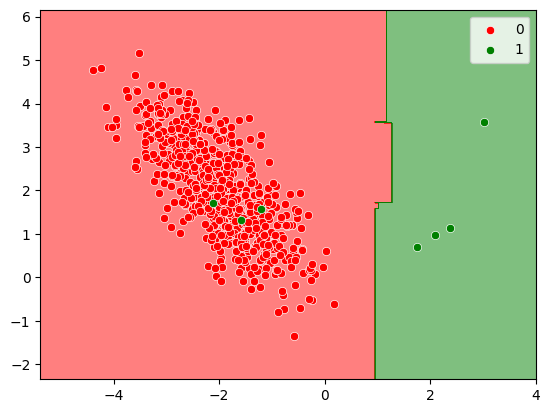

In [121]:
X_set, y_set = X_train.values, y_train

colors=('red', 'green')
cmap = ListedColormap(colors)

X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
step=0.01

X1, X2 = np.meshgrid(
    np.arange(X1_min, X1_max, step),
    np.arange(X2_min, X2_max, step)
)


arr = np.array([X1.ravel(), X2.ravel()])
classifier.fit(X_train, y_train)
Z = classifier.predict(arr.T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.5, cmap=cmap)

for i, j in enumerate(np.unique(y_set)):

    xi = X_set[y_set == j, 0]
    yi = X_set[y_set == j, 1]

    sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)

In [122]:
def plot_decision_boundary(classifier, X_train, X_test, y_train, y_test):
    X_set, y_set = X_train.values, y_train

    colors=('red', 'green')
    cmap = ListedColormap(colors)

    X1_min, X1_max = X_set[:,0].min() - 1, X_set[:,0].max() + 1
    X2_min, X2_max = X_set[:,1].min() - 1, X_set[:,1].max() + 1
    step=0.01

    X1, X2 = np.meshgrid(
        np.arange(X1_min, X1_max, step),
        np.arange(X2_min, X2_max, step)
    )


    arr = np.array([X1.ravel(), X2.ravel()])
    classifier.fit(X_train, y_train)
    Z = classifier.predict(arr.T)
    Z = Z.reshape(X1.shape)

    plt.contourf(X1, X2, Z, alpha=0.5, cmap=cmap)

    X_test = X_test.values
    for i, j in enumerate(np.unique(y_test)):

        xi = X_test[y_test == j, 0]
        yi = X_test[y_test == j, 1]

        sns.scatterplot(x=xi, y=yi, c=colors[i], label=j)

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


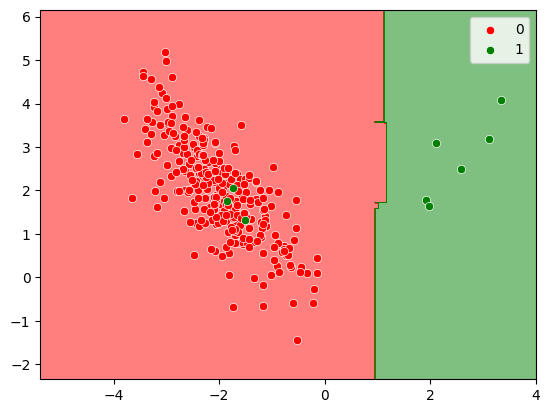

In [123]:
plot_decision_boundary(classifier, X_resampled, X_test, y_resampled, y_test)

In [124]:
from sklearn.tree import DecisionTreeClassifier

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


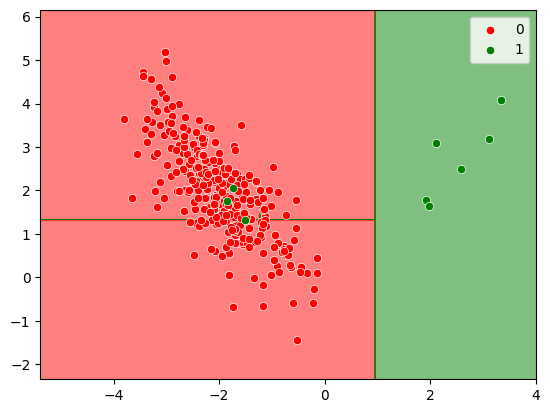

In [125]:
dt = DecisionTreeClassifier()
plot_decision_boundary(dt, X_train, X_test, y_train, y_test)

In [126]:
from sklearn.naive_bayes import GaussianNB

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


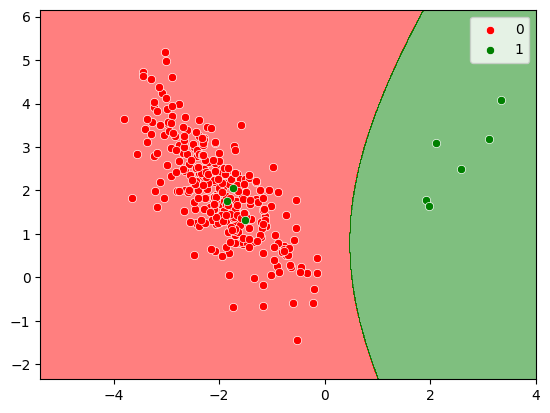

In [127]:
GNB = GaussianNB()
plot_decision_boundary(GNB, X_train, X_test, y_train, y_test)

In [128]:
from sklearn.naive_bayes import MultinomialNB

In [129]:
MNB = MultinomialNB()
# plot_decision_boundary(MNB, X_train, X_test, y_train, y_test)

In [130]:
from sklearn.svm import SVC

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


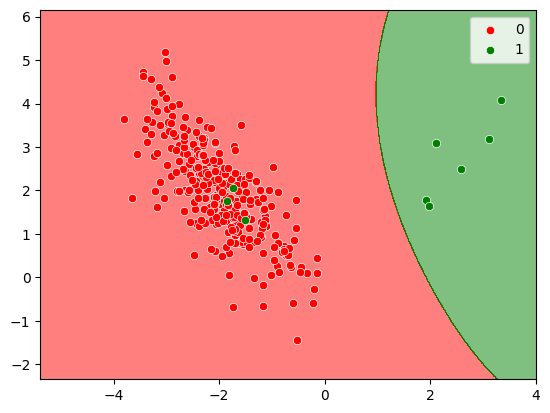

In [131]:
SVM = SVC(C=1, gamma=.05)
plot_decision_boundary(SVM, X_train, X_test, y_train, y_test)

/home/max/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


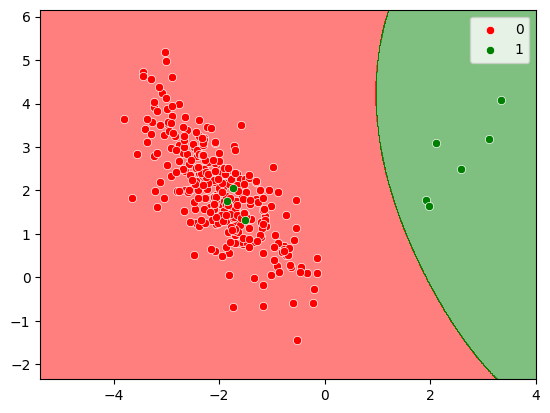

In [132]:
SVM = SVC(C=1, gamma=.05)
plot_decision_boundary(SVM, X_resampled, X_test, y_resampled, y_test)